# 📱 Liquidity Stress Prediction Challenge - Starter Notebook

Welcome to the starter notebook for this challenge.

In this challenge, your goal is to build a machine learning model that predicts whether a customer is likely to experience liquidity stress, using historical mobile money behaviour.

This notebook walks through a simple end-to-end pipeline:

- Loading and exploring the data
- Preprocessing
- Training a baseline model
- Evaluating performance
- Generating predictions for submission

The baseline model used here is **Logistic Regression**, which is a good starting point for tabular classification problems.


In [1]:
# 📚 Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
# 📥 Load the Data
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

SUBMISSION_TARGET = "Target"

# Create a sample submission template directly from the test IDs
sample_submission = pd.DataFrame({
    "ID": test["ID"],
    SUBMISSION_TARGET: 0.5
})

# Peek at the data
train.head()


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

## 🔍 Exploratory Data Analysis (EDA)

Let’s explore the training data to understand the features and target.


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 184 entries, arpu to ID
dtypes: float64(134), int64(44), object(6)
memory usage: 56.2+ MB


In [4]:
train[train.isna().any(axis=1)]

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

In [5]:
train.dtypes

arpu                         float64
age                            int64
gender                        object
region                        object
smartphone                    object
                              ...   
m4_daily_avg_bal             float64
m5_daily_avg_bal             float64
m6_daily_avg_bal             float64
liquidity_stress_next_30d      int64
ID                            object
Length: 184, dtype: object

In [6]:
# Check missing values
missing_summary = train.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(20)


Series([], dtype: int64)

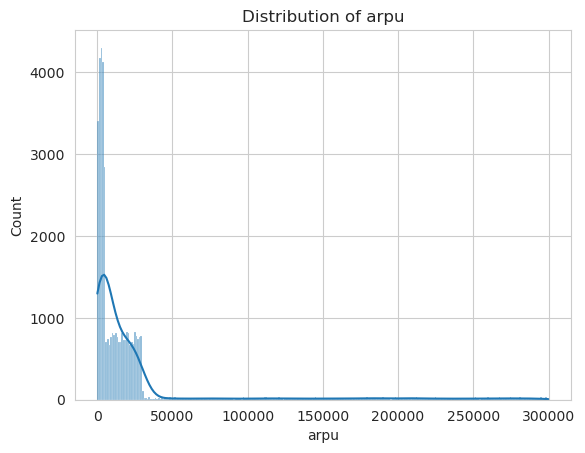

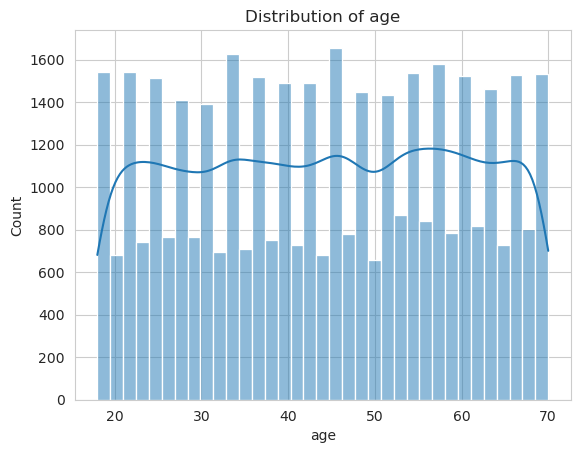

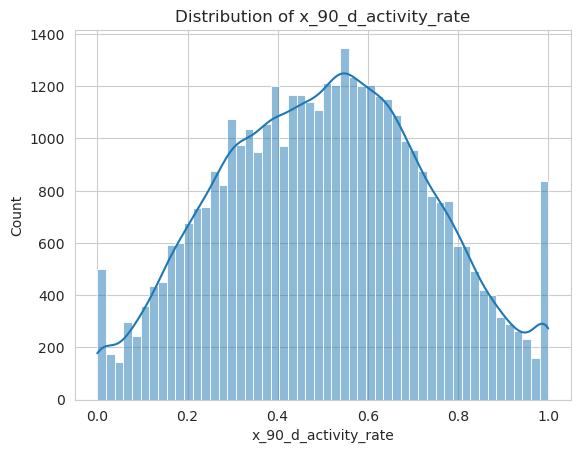

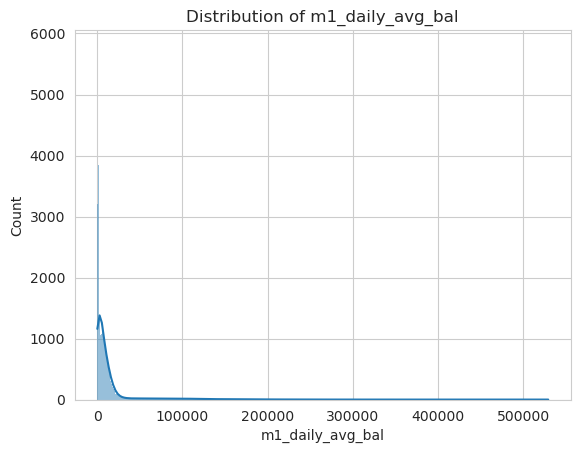

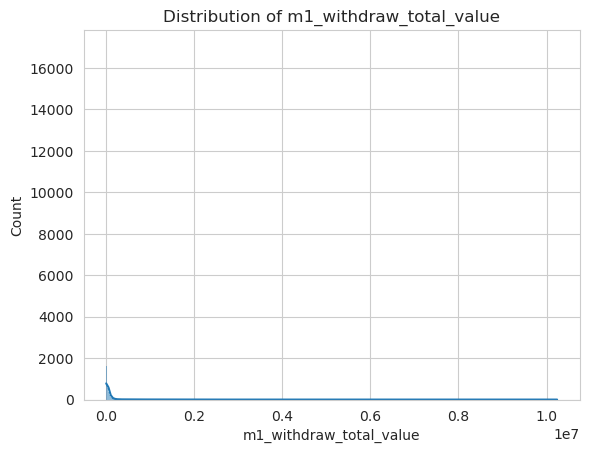

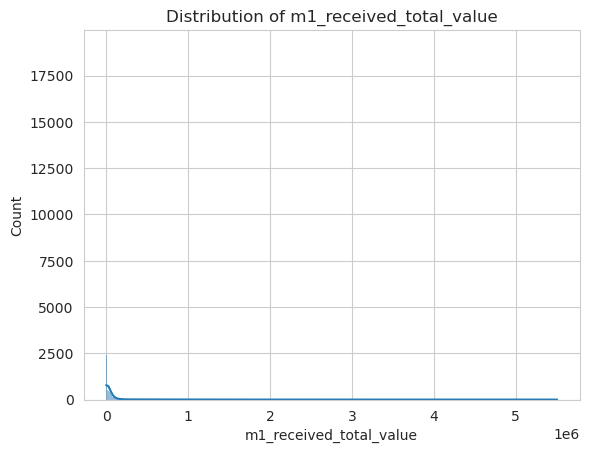

In [7]:
# Plot distributions of a few useful numeric features
num_features = [
    "arpu",
    "age",
    "x_90_d_activity_rate",
    "m1_daily_avg_bal",
    "m1_withdraw_total_value",
    "m1_received_total_value"
]

for col in num_features:
    if col in train.columns:
        sns.histplot(train[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()


In [8]:
TARGET = "liquidity_stress_next_30d	"

In [9]:
# Distribution of target variable
ax = sns.countplot(x=TARGET, data=train)
plt.title("Liquidity Stress Distribution")
plt.xlabel("Liquidity Stress (Next 30 Days)")
plt.ylabel("Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f"{count}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.show()


ValueError: Could not interpret value `liquidity_stress_next_30d	` for `x`. An entry with this name does not appear in `data`.

### 🏷️ Encoding Categorical Variables

We use **one-hot encoding** to convert categorical columns into numeric format so they can be used by the model.


In [10]:
# Identify the ID column, target column and feature columns
TARGET = "liquidity_stress_next_30d"
ID_COL = "ID"

feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
cat_cols = train[feature_cols].select_dtypes(include="object").columns.tolist()
num_cols = train[feature_cols].select_dtypes(include=["float64", "int64"]).columns.tolist()



In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)
model_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=30,
            criterion="entropy",
            class_weight=None,
            min_samples_leaf=50,
            min_samples_split=10,
            max_features="sqrt",
            oob_score=True,
            random_state=42,
            n_jobs=-1
            ))
    ]
)
model_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [12]:
X = train[feature_cols]
y = train[TARGET]

In [13]:
splitter = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.3,
    random_state=42
)
splitter

StratifiedShuffleSplit(n_splits=5, random_state=42, test_size=0.3,
            train_size=None)

In [14]:
train_idx, val_idx = next(splitter.split(X, y))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]


In [16]:
model_pipeline.fit(X_train, y_train)
val_pred_prob = model_pipeline.predict_proba(X_val)[:,1]
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))

Validation ROC-AUC: 0.7925318082788672


In [17]:
# Predict on validation set
from sklearn.metrics import log_loss
val_pred_prob = model_pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))
print("Validation Log Loss:", log_loss(y_val, val_pred_prob))
print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


Validation ROC-AUC: 0.7925318082788672
Validation Log Loss: 0.3616898729195111

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10200
           1       0.94      0.04      0.08      1800

    accuracy                           0.86     12000
   macro avg       0.90      0.52      0.50     12000
weighted avg       0.87      0.86      0.80     12000



## 🧹 Preprocessing

We’ll split the training data into features and target, then create a validation set.


## 🤖 Model Training

We’ll use a Logistic Regression classifier as our baseline model.


In [18]:
def evaluation_metrics(y_val, val_pred_prob):
    val_log_loss = log_loss(y_val, val_pred_prob)
    val_roc_auc = roc_auc_score(y_val, val_pred_prob)
    combined_score = 0.6 * (1 - val_log_loss) + 0.4 * val_roc_auc   # higher = better
    return {
        "Validation Log Loss": val_log_loss,
        "Validation ROC-AUC": val_roc_auc,
        "Combined Score": combined_score
    }

In [19]:

# Predict on validation set
val_pred_prob = model_pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
val_evaluation = evaluation_metrics(y_val, val_pred_prob)
for name, value in val_evaluation.items():
    print(f"{name}: {value}")

print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


Validation Log Loss: 0.3616898729195111
Validation ROC-AUC: 0.7925318082788672
Combined Score: 0.6999987995598402

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10200
           1       0.94      0.04      0.08      1800

    accuracy                           0.86     12000
   macro avg       0.90      0.52      0.50     12000
weighted avg       0.87      0.86      0.80     12000



In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, log_loss, roc_auc_score
from scipy.stats import randint

def combined_score(y_true, y_pred_proba):
    ll = log_loss(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    return 0.6 * (1 - ll) + 0.4 * auc

combined_scorer = make_scorer(combined_score, response_method="predict_proba", greater_is_better=True)

rf_param_dist = {
    "model__n_estimators": [200, 300, 500],       # fewer trees during search = faster; bump up for final model
    "model__max_depth": [10, 15, 20, 30, None],
    "model__min_samples_leaf": randint(5, 100),     # smoothing/calibration knob (matters a lot for Log Loss)
    "model__min_samples_split": randint(2, 50),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
    "model__class_weight": ["balanced_subsample", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator=model_pipeline,   # swap in your RF-based pipeline
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV Combined Score:", rf_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

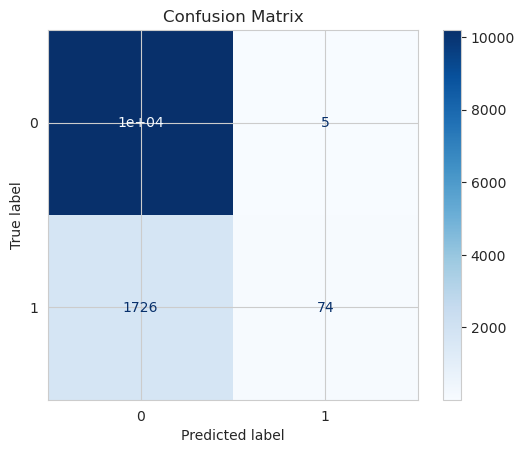

In [20]:
# 📈 Evaluate Model on Validation Set
cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


### Attempt cross-validation to find best hyper-parameters for logistic regression

In [21]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, log_loss, roc_auc_score

def combined_score(y_true, y_pred_proba):
    ll = log_loss(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    return 0.6 * (1 - ll) + 0.4 * auc

Exception ignored in: <function ResourceTracker.__del__ at 0x7288b8ba4040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7dc8bcfa8040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

In [106]:
model_pipeline.set_params(
    model__solver="saga",
    model__max_iter=2000,
    model__random_state=42
)
parameters = {
    "model__C": [0.01, 1, 10],
    "model__l1_ratio": np.arange(0, 1.01, 0.25).tolist(),
    "model__class_weight": ["balanced", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

combined_scorer = make_scorer(combined_score, response_method="predict_proba", greater_is_better=True)

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=parameters,
    n_iter=5,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

"""
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)
"""

'\ngrid_search = GridSearchCV(\n    estimator=model_pipeline,\n    param_grid=param_grid,\n    scoring=combined_scorer,\n    cv=cv,\n    n_jobs=-1,\n    verbose=1\n)\n'

In [22]:
rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': ['balanced_subsample', None], 'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....x74db65ac3230>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(c...redict_proba')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there

Exception ignored in: <function ResourceTracker.__del__ at 0x73080f7a8040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7b648a988040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

In [ ]:
print("Best params:", rf_search.best_params_)
print("Best CV Combined Score:", rf_search.best_score_)

best_model = rf_search.best_estimator_
val_pred_prob = best_model.predict_proba(X_val)[:, 1]

val_evaluation = evaluation_metrics(y_val, val_pred_prob)
for name, value in val_evaluation.items():
    print(f"{name}: {value}")

Best params: {'model__l1_ratio': 0.5, 'model__class_weight': None, 'model__C': 1}
Best CV Combined Score: 0.674330775915997
Validation Log Loss: 0.37761078160288447
Validation ROC-AUC: 0.7507031862745097
Combined Score: 0.6737148055480733


## 📊 Optional: Feature Importance

This section gives a quick sense of which features are most useful to the baseline model. It is optional and can be skipped if you only want to generate a first submission quickly.


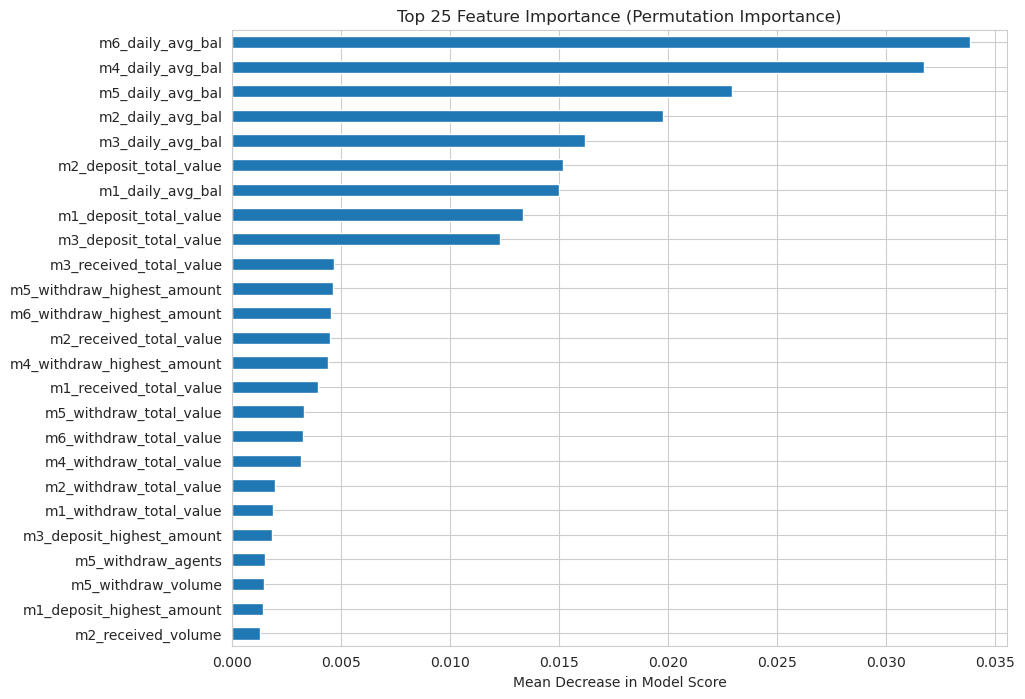

In [23]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    rf_search,
    X_val,
    y_val,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X.columns)

(
    importances
    .sort_values(ascending=False)
    .head(25)
    .sort_values()
    .plot(kind="barh", figsize=(10,8))
)

plt.title("Top 25 Feature Importance (Permutation Importance)")
plt.xlabel("Mean Decrease in Model Score")
plt.show()


## 🚀 Predictions on Test Set

Let’s predict on the test set and generate a submission file.

The submission file must contain two columns:

- `ID`: the customer ID from the test set
- `Target`: the predicted probability that the customer will experience liquidity stress in the next 30 days

`Target` should be a probability between 0 and 1, not a hard class label.


In [24]:
# Retrain the model on the full training set
rf_search.best_estimator_.fit(X, y)

Exception ignored in: <function ResourceTracker.__del__ at 0x7b79d95a8040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7e0482f88040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

KeyboardInterrupt: 

In [ ]:
# Predict probabilities on test data
test_predictions =  rf_search.best_estimator_.predict_proba(test[feature_cols])[:, 1]

In [75]:
# Prepare submission
submission = sample_submission.copy()
submission[SUBMISSION_TARGET] = test_predictions

# Save to CSV
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

submission.head()


Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.111618
1,ID_29975A9C7E,0.096319
2,ID_F59CE25650,0.098509
3,ID_E875F68D1A,0.056391
4,ID_2902B1C0D0,0.057712


Exception ignored in: <function ResourceTracker.__del__ at 0x7fccbf7a0040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7aa6d538c040>
Traceback (most recent call last):
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bode-murairi/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception igno

## ✅ What’s Next?

This is just a baseline model. You are welcome to improve upon it or design your own pipeline from scratch!

Good luck, and happy modelling! 🚀
